# Paper-matched 6-PLD DNN training

This notebook follows the reference notebook: paper-matched physics, dense noise-SD sampling, Rician `mc + ml` inputs, separate CBF/ATT networks, MAE loss, and early stopping through a 200-epoch maximum.

In [1]:
import sys, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
project_root = Path.cwd().parent if not (Path.cwd() / 'src').exists() else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))
from simulation import SimulationConfig, seed_everything, generate_dataset, select_inputs, paper_signal, reference_signal, RESULTS
cfg = SimulationConfig(); SEED = 42
seed_everything(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('6 PLDs:', cfg.plds_6_s)
print('Reference four PLDs:', cfg.plds_4_s)
print('Reference signal:', reference_signal(cfg))

Device: cuda
6 PLDs: (1.525, 2.025, 2.525, 3.025, 3.525, 4.025)
Reference four PLDs: (1.525, 2.025, 2.525, 3.025)
Reference signal: 334.20389639412525


In [2]:
N_TRAIN, N_VAL = 4000, 1000
X_train_full, Y_train, _ = generate_dataset(N_TRAIN, cfg, SEED + 10, snr=10.0)
X_val_full, Y_val, _ = generate_dataset(N_VAL, cfg, SEED + 20, snr=10.0)
X_train = select_inputs(X_train_full, cfg, '6_pld')
X_val = select_inputs(X_val_full, cfg, '6_pld')
X_mean = X_train.mean(0, keepdims=True).astype('float32'); X_std = X_train.std(0, keepdims=True).astype('float32') + 1e-8
X_train = ((X_train-X_mean)/X_std).astype('float32'); X_val = ((X_val-X_mean)/X_std).astype('float32')
CBF_mean, CBF_std = float(Y_train[:,0].mean()), float(Y_train[:,0].std()+1e-8)
ATT_mean, ATT_std = float(Y_train[:,1].mean()), float(Y_train[:,1].std()+1e-8)
print('Train:', X_train.shape, Y_train.shape, 'Validation:', X_val.shape, Y_val.shape)
print('Target ranges CBF/ATT:', (Y_train[:,0].min(),Y_train[:,0].max()), (Y_train[:,1].min(),Y_train[:,1].max()))

Train: (4000, 6) (4000, 2) Validation: (1000, 6) (1000, 2)
Target ranges CBF/ATT: (np.float32(0.0071000634), np.float32(99.87163)) (np.float32(0.5003694), np.float32(2.9997208))


In [3]:
class StandardizedNet(nn.Module):
    def __init__(self, input_dim, width):
        super().__init__(); layers=[nn.Linear(input_dim,width),nn.ELU()]
        for _ in range(8): layers += [nn.Linear(width,width),nn.ELU()]
        layers.append(nn.Linear(width,1)); self.backbone=nn.Sequential(*layers)
        for layer in self.backbone:
            if isinstance(layer,nn.Linear): nn.init.kaiming_normal_(layer.weight,nonlinearity='relu'); nn.init.zeros_(layer.bias)
    def forward(self,x): return self.backbone(x)

def train_net(net, x_train, y_train, x_val, y_val, mean, std, name):
    yt=((y_train-mean)/std).astype('float32'); yv=((y_val-mean)/std).astype('float32')
    train_loader=DataLoader(TensorDataset(torch.from_numpy(x_train),torch.from_numpy(yt[:,None])),batch_size=512,shuffle=True)
    val_loader=DataLoader(TensorDataset(torch.from_numpy(x_val),torch.from_numpy(yv[:,None])),batch_size=512)
    opt=torch.optim.Adam(net.parameters(),lr=1e-3); loss_fn=nn.L1Loss(); best=float('inf'); state=copy.deepcopy(net.state_dict()); stale=0; rows=[]
    for epoch in range(1,201):
        net.train(); train_loss=0
        for xb,yb in train_loader:
            opt.zero_grad(); loss=loss_fn(net(xb.to(device)),yb.to(device)); loss.backward(); torch.nn.utils.clip_grad_norm_(net.parameters(),1.0); opt.step(); train_loss+=loss.item()
        net.eval(); val_loss=sum(loss_fn(net(xb.to(device)),yb.to(device)).item() for xb,yb in val_loader)/len(val_loader); train_loss/=len(train_loader)
        rows.append({'epoch':epoch,'train_mae':train_loss,'validation_mae':val_loss}); print(f'{name} epoch {epoch:03d}/200 train={train_loss:.6f} val={val_loss:.6f}')
        if val_loss<best: best=val_loss; state=copy.deepcopy(net.state_dict()); stale=0
        else:
            stale+=1
            if stale>=20: print(name,'early stopped at',epoch); break
    net.load_state_dict(state); return pd.DataFrame(rows)
CBFnet=StandardizedNet(6,50).to(device); ATTnet=StandardizedNet(6,100).to(device)
CBF_history=train_net(CBFnet,X_train,Y_train[:,0],X_val,Y_val[:,0],CBF_mean,CBF_std,'CBF-6PLD')
ATT_history=train_net(ATTnet,X_train,Y_train[:,1],X_val,Y_val[:,1],ATT_mean,ATT_std,'ATT-6PLD')
display(CBF_history.tail()); display(ATT_history.tail())

CBF-6PLD epoch 001/200 train=0.703259 val=0.386896
CBF-6PLD epoch 002/200 train=0.282820 val=0.225018
CBF-6PLD epoch 003/200 train=0.193927 val=0.200839
CBF-6PLD epoch 004/200 train=0.191477 val=0.178897
CBF-6PLD epoch 005/200 train=0.164857 val=0.160288
CBF-6PLD epoch 006/200 train=0.164012 val=0.161068
CBF-6PLD epoch 007/200 train=0.160133 val=0.152856
CBF-6PLD epoch 008/200 train=0.144064 val=0.148592
CBF-6PLD epoch 009/200 train=0.137497 val=0.135447
CBF-6PLD epoch 010/200 train=0.140908 val=0.188713
CBF-6PLD epoch 011/200 train=0.150442 val=0.139973
CBF-6PLD epoch 012/200 train=0.133692 val=0.141677
CBF-6PLD epoch 013/200 train=0.131643 val=0.128924
CBF-6PLD epoch 014/200 train=0.127932 val=0.136439
CBF-6PLD epoch 015/200 train=0.131469 val=0.126868
CBF-6PLD epoch 016/200 train=0.126315 val=0.144925
CBF-6PLD epoch 017/200 train=0.139559 val=0.135740
CBF-6PLD epoch 018/200 train=0.129615 val=0.141044
CBF-6PLD epoch 019/200 train=0.133485 val=0.144865
CBF-6PLD epoch 020/200 train=0.

,epoch,train_mae,validation_mae
36,37,0.124848,0.130961
37,38,0.121098,0.134350
38,39,0.123782,0.133451
39,40,0.123186,0.124539
40,41,0.124024,0.140718


,epoch,train_mae,validation_mae
84,85,0.288500,0.355135
85,86,0.278582,0.347591
86,87,0.285481,0.350958
87,88,0.296234,0.365019
88,89,0.293722,0.360166


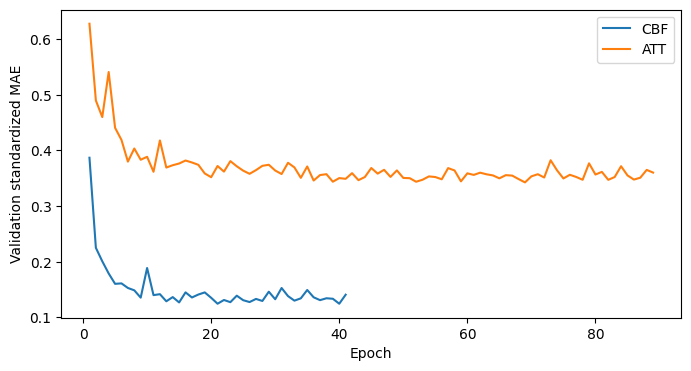

Saved: D:\fiinal year project\dnn_pld_reduction\results\model_6_pld


In [4]:
output_dir=RESULTS/'model_6_pld'; output_dir.mkdir(parents=True,exist_ok=True)
torch.save(CBFnet.state_dict(),output_dir/'cbf_model.pt'); torch.save(ATTnet.state_dict(),output_dir/'att_model.pt')
CBF_history.to_csv(output_dir/'cbf_training_history.csv',index=False); ATT_history.to_csv(output_dir/'att_training_history.csv',index=False)
np.savez(output_dir/'normalization.npz',X_mean=X_mean,X_std=X_std,CBF_mean=CBF_mean,CBF_std=CBF_std,ATT_mean=ATT_mean,ATT_std=ATT_std)
(output_dir/'config.json').write_text(json.dumps({'input_dim':6,'plds_s':list(cfg.plds_6_s),'max_epochs':200,'patience':20,'loss':'MAE','noise':'dense SD Rician mc+ml'},indent=2),encoding='utf-8')
plt.figure(figsize=(8,4)); plt.plot(CBF_history.epoch,CBF_history.validation_mae,label='CBF'); plt.plot(ATT_history.epoch,ATT_history.validation_mae,label='ATT'); plt.xlabel('Epoch'); plt.ylabel('Validation standardized MAE'); plt.legend(); plt.show(); print('Saved:',output_dir)